# Initialization

These are the models we've chosen for the demonstration:

General purpose
- text-embedding-3-large, OpenAI
- voyage-large-2, VoyageAI
- gte-large-en-v1.5, Alibaba
- jina-embeddings-v3, JinaAI

Biological
- MedEmbed-small-v0.1
- BioBERT-mnli-snli-scinli-scitail-mednli-stsb

Trending
- Modernbert

In [1]:
!pip install -r requirements.txt -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import random
import ssl
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

import nltk
from nltk.corpus import wordnet

import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

import tiktoken
from openai import OpenAI
import voyageai

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
from google.colab import userdata

OPEN_AI_KEY = userdata.get('OPEN_AI_KEY')
VOYAGE_AI_KEY = userdata.get('VOYAGE_AI_KEY')

In [4]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Voyage
https://blog.voyageai.com/2024/05/05/voyage-large-2-instruct-instruction-tuned-and-rank-1-on-mteb/

https://docs.voyageai.com/docs/embeddings

In [6]:
vo = voyageai.Client(api_key=VOYAGE_AI_KEY)
tokenizer_voyage = AutoTokenizer.from_pretrained("voyageai/voyage-large-2", legacy=False)

def get_voyageai(texts):
    embeddings = vo.embed(texts, model="voyage-large-2", input_type="document").embeddings
    return embeddings

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Alibaba

https://huggingface.co/Alibaba-NLP/gte-large-en-v1.5

In [7]:
tokenizer_alibaba = AutoTokenizer.from_pretrained('Alibaba-NLP/gte-large-en-v1.5')
model_alibaba = AutoModel.from_pretrained('Alibaba-NLP/gte-large-en-v1.5', trust_remote_code=True).to(device)

def get_alibaba(texts):
    batch_dict_alibaba = tokenizer_alibaba(texts, max_length=512, padding=True, truncation=True, return_tensors='pt').to(device)
    outputs_alibaba = model_alibaba(**batch_dict_alibaba)
    embeddings_alibaba = F.normalize(outputs_alibaba.last_hidden_state[:, 0], p=2, dim=1).tolist()
    return embeddings_alibaba

## Jina

https://huggingface.co/jinaai/jina-embeddings-v3

In [8]:
tokenizer_jina = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True)
model_jina = AutoModel.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True, revision="main").to(device)


def get_jina(texts, task="text-matching", max_length=512, truncate_dim=None):
    encoded_input = tokenizer_jina(texts, padding=True, truncation=True, max_length=max_length, return_tensors='pt').to(device)
    with torch.inference_mode():
        embeddings = model_jina.encode(texts, task=task, max_length=max_length, truncate_dim=truncate_dim)
    return F.normalize(torch.tensor(embeddings), p=2, dim=1).numpy()

/usr/local/lib/python3.10/dist-packages/flash_attn/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(
/usr/local/lib/python3.10/dist-packages/flash_attn/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dout, *args):


## OpenAI

https://platform.openai.com/docs/guides/embeddings#embedding-models

In [9]:
client = OpenAI(api_key=OPEN_AI_KEY)
tokenizer_openai = tiktoken.encoding_for_model("text-embedding-3-large")

def get_openai(texts):
    response = client.embeddings.create(input=texts, model="text-embedding-3-large")
    return [item.embedding for item in response.data]

## BioBert

https://huggingface.co/pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb

In [10]:
tokenizer_biobert = AutoTokenizer.from_pretrained('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')
model_biobert = AutoModel.from_pretrained('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb').to(device)

def get_biobert(texts):
    encoded_input_biobert = tokenizer_biobert(texts, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
    with torch.no_grad():
        model_output_biobert = model_biobert(**encoded_input_biobert)
    embeddings_biobert = mean_pooling(model_output_biobert, encoded_input_biobert['attention_mask'])
    embeddings_biobert = F.normalize(embeddings_biobert, p=2, dim=1).tolist()
    return embeddings_biobert

## MedEmbed

https://huggingface.co/abhinand/MedEmbed-small-v0.1

In [11]:
tokenizer_medembed = AutoTokenizer.from_pretrained('abhinand/MedEmbed-small-v0.1')
model_medembed = AutoModel.from_pretrained('abhinand/MedEmbed-small-v0.1').to(device)


def get_medembed(texts):
    encoded_input_medembed = tokenizer_medembed(texts, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
    with torch.no_grad():
        model_output_medembed = model_medembed(**encoded_input_medembed)
    embeddings_medembed = mean_pooling(model_output_medembed, encoded_input_medembed['attention_mask'])
    embeddings_medembed = F.normalize(embeddings_medembed, p=2, dim=1).tolist()
    return embeddings_medembed

## ModernBERT

https://huggingface.co/blog/modernbert

In [12]:
tokenizer_modernbert = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
model_modernbert = AutoModel.from_pretrained("answerdotai/ModernBERT-base", torch_dtype=torch.float16).to(device)

def get_modernbert(texts):
    encoded_input_modernbert = tokenizer_modernbert(texts, padding=True, truncation=True, return_tensors="pt", max_length=512).to(device)
    with torch.no_grad():
        model_output_modernbert = model_modernbert(**encoded_input_modernbert)
    embeddings_modernbert = mean_pooling(model_output_modernbert, encoded_input_modernbert['attention_mask'])
    embeddings_modernbert = F.normalize(embeddings_modernbert, p=2, dim=1).tolist()
    return embeddings_modernbert

You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.


In [13]:
models = [
    ("openai", get_openai, tokenizer_openai),
    ("voyage", get_voyageai, tokenizer_voyage),
    ("alibaba", get_alibaba, tokenizer_alibaba),
    ("jina", get_jina, tokenizer_jina),
    ("biobert", get_biobert, tokenizer_biobert),
    ("medembed", get_medembed, tokenizer_medembed),
    ("modernbert", get_modernbert, tokenizer_modernbert)
]

In [14]:
def get_embeddings(texts, model, method, batch_size=8):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Processing {model}"):
        batch_texts = texts[i:i + batch_size]
        batch_embeddings = method(batch_texts)
        embeddings.extend(batch_embeddings)
    return embeddings

# Queries embeddings

In [15]:
queries_pairs = [
    ("Сonnection between LDH markers and persistent exhaustion", "How are lactate dehydrogenase levels and chronic fatigue related?"),
    ("What published data is available for impact on daily activities with anti-C5 therapy?", "Is there evidence on how C5i impacts patients' ability to perform daily tasks?"),
    ("Is fingolimod a comparable alternative to dimethyl fumarate in multiple sclerosis management?", "Can Gilenya be used as a replacement for Tecfidera in treating multiple sclerosis?"),
    ("Managing PNH via IVH control.", "Addressing paroxysmal nocturnal hemoglobinuria through the regulation of intravascular hemolysis."),
    ("Do high D dimer levels influence the risk of developing blood clots?", "What is the relationship between elevated D-dimer levels and thrombosis risk?"),
    ("How long have you been ill?", "Since when have you been experiencing these symptoms?"),
    ("Optical coherence tomography applications in diagnosing retinal diseases.", "What is the use of OCT in clinical assessments for retinal disorders?"),
    ("Symptoms of anemia?", "How does anemia manifest?"),
    ("The advantages of maintaining a fitness routine.", "What are the health benefits of regular physical activity")
]

In [16]:
queries_df = pd.DataFrame(queries_pairs, columns=["question 1", "question 2"])
queries_df.head()

,question 1,question 2
0,Сonnection between LDH markers and persistent ...,How are lactate dehydrogenase levels and chron...
1,What published data is available for impact on...,Is there evidence on how C5i impacts patients'...
2,Is fingolimod a comparable alternative to dime...,Can Gilenya be used as a replacement for Tecfi...
3,Managing PNH via IVH control.,Addressing paroxysmal nocturnal hemoglobinuria...
4,Do high D dimer levels influence the risk of d...,What is the relationship between elevated D-di...


Processing openai:   0%|          | 0/2 [00:00<?, ?it/s]

Processing openai:   0%|          | 0/2 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/2 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/2 [00:00<?, ?it/s]

Processing alibaba:   0%|          | 0/2 [00:00<?, ?it/s]

...

Processing biobert:   0%|          | 0/2 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/2 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/2 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/2 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/2 [00:00<?, ?it/s]

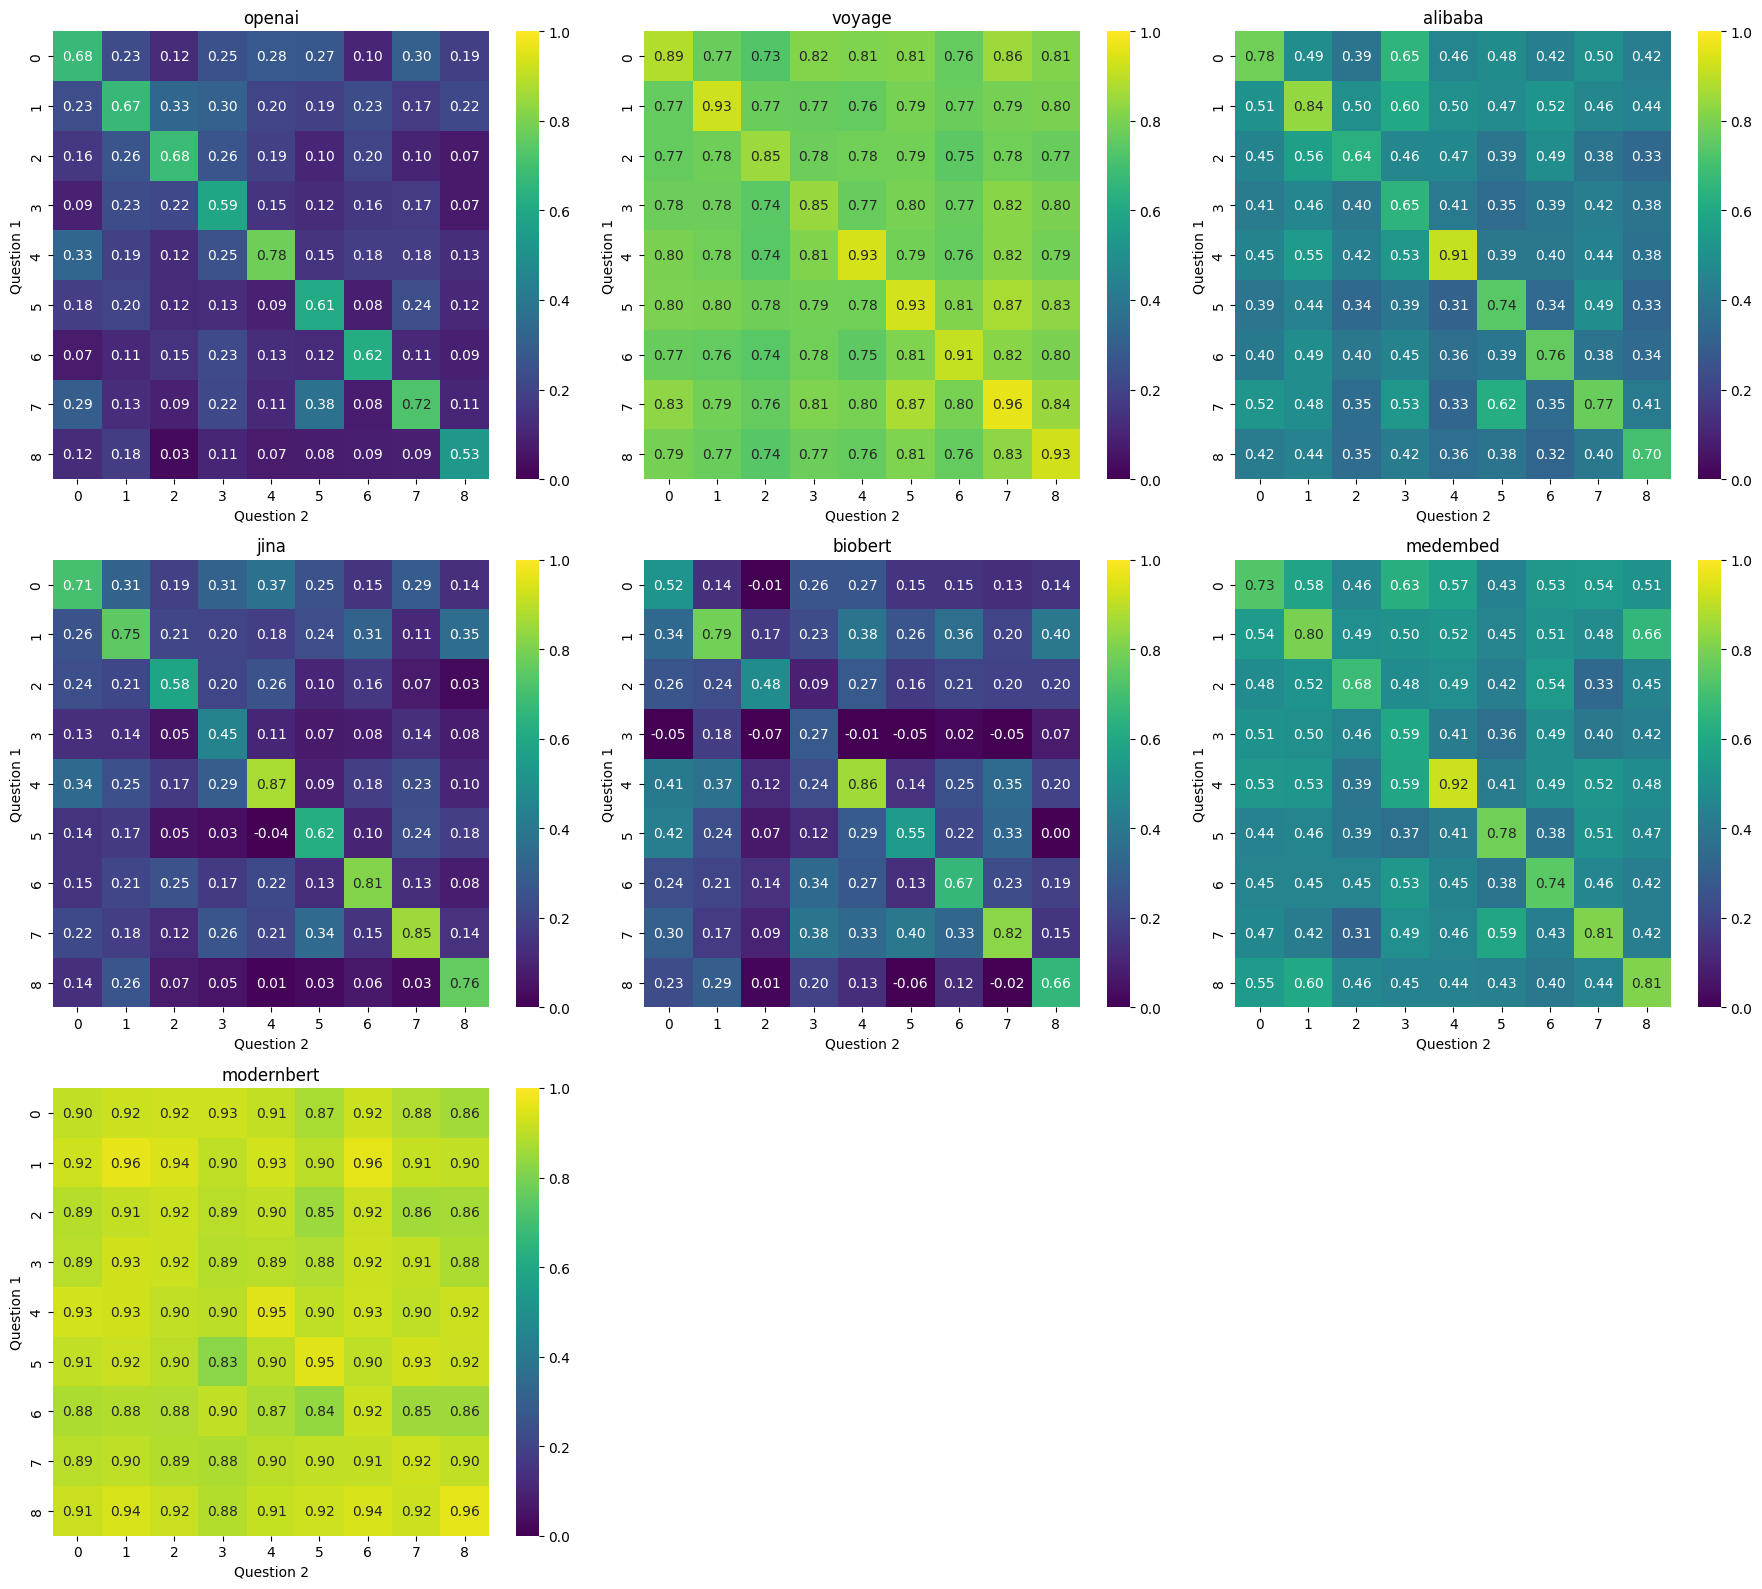

In [17]:
plt.figure(figsize=(18, 16))

for i, (model, method, _) in enumerate(models, start=1):
    embeddings_q1 = get_embeddings(queries_df["question 1"].tolist(), model, method)
    embeddings_q2 = get_embeddings(queries_df["question 2"].tolist(), model, method)

    similarity_matrix = cosine_similarity(embeddings_q1, embeddings_q2)

    plt.subplot(3, 3, i)  # lines, columns, i
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='viridis', cbar=True, vmin=0, vmax=1)
    plt.title(model)

    plt.xlabel('Question 2')
    plt.ylabel('Question 1')

plt.tight_layout()
plt.show()

# Documents embeddings

For the demo we've downloaded from [PubMed](https://pubmed.ncbi.nlm.nih.gov/) all papers for these [MeSH terms](https://meshb.nlm.nih.gov/treeView) for last 5 years:

- Diabetes, Gestational [C19.246.200] (6366 abstracts).

In [22]:
gestational_df = pd.read_csv('data/gestational.csv')

In [23]:
for model, method, _ in models:
    gestational_df[model] = get_embeddings(gestational_df['text'].tolist(), model, method)

Processing openai:   0%|          | 0/592 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/592 [00:00<?, ?it/s]

Processing alibaba:   0%|          | 0/592 [00:00<?, ?it/s]

Processing jina:   0%|          | 0/592 [00:00<?, ?it/s]

Processing biobert:   0%|          | 0/592 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/592 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/592 [00:00<?, ?it/s]

# How documents and queries work together

In [24]:
def plot_violin(df, category_descriptions):
    n_cols, n_rows = 4, (len(models) + 3) // 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    global_ylim = (0, 1)

    for i, (model, method, _) in enumerate(models):
        similarities, categories = [], []
        for category_description in category_descriptions:
            sims = cosine_similarity(df[model].tolist(), get_embeddings([category_description], model, method)).flatten()
            similarities.extend(sims)
            categories.extend([category_description] * len(sims))
        ax = axes[i // n_cols, i % n_cols]

        titles = ["LADA" if desc == "Latent autoimmune diabetes in adults" else desc for desc in categories]
        sns.violinplot(
            x=titles,
            y=similarities, ax=ax
        )
        ax.set_title(f"Model: {model}")
        ax.set_ylim(global_ylim)

    for j in range(len(models), n_rows * n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])

    plt.tight_layout()
    plt.show()

Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/1 [00:00<?, ?it/s]

Processing alibaba:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processing biobert:   0%|          | 0/1 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/1 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/1 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/1 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/1 [00:00<?, ?it/s]

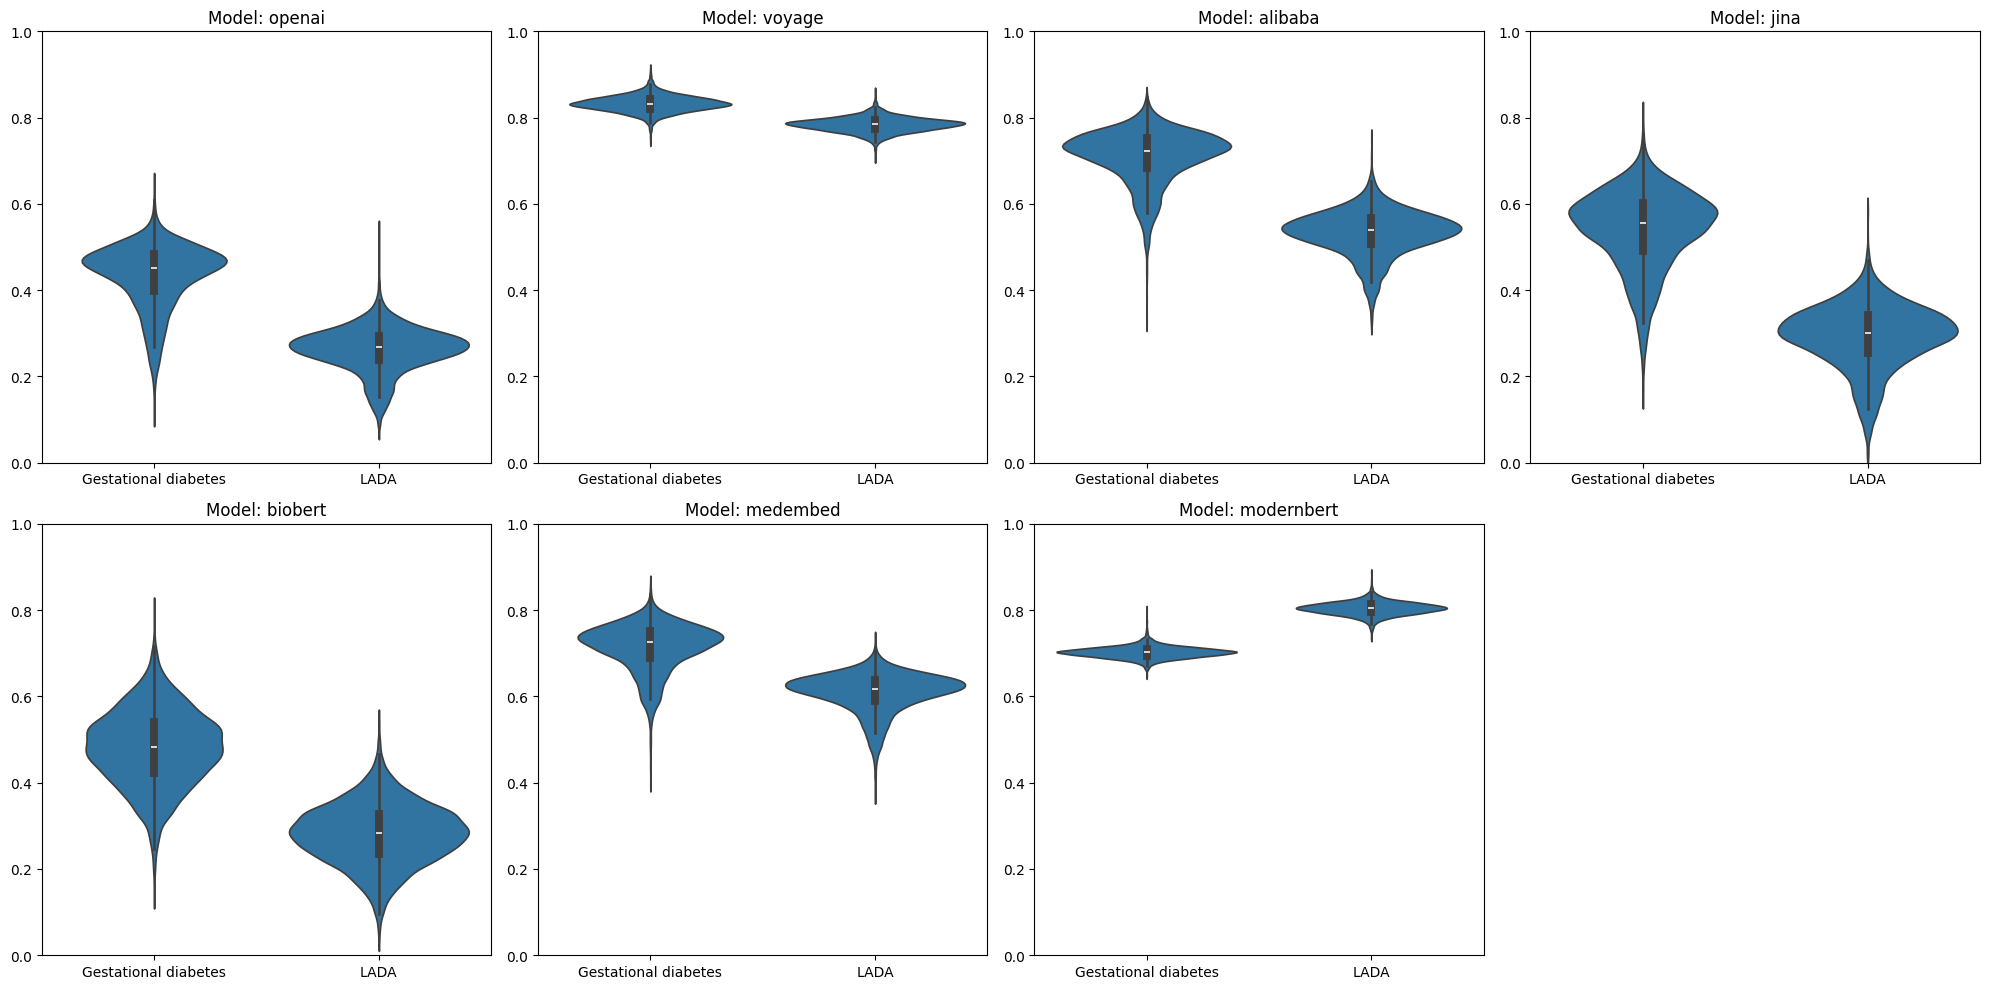

In [25]:
plot_violin(gestational_df, ["Gestational diabetes", "Latent autoimmune diabetes in adults"])

# Tolerance to spelling errors

## Typos

You can take typos from logs, create them manually or generate ([typo](https://pypi.org/project/typo/)). Anyway, make sure that typos of varoius types are represented.

In [26]:
typos = {
    'willebrand disease': 'xillebrand disease',  # error in the beginning
    'ozempik': '0zempik',  # similar char in the beginning
    'patient': 'aptient',  # char swap in the beginning
    'pregnancy': 'regnancy',  # missing char in the beginning

    'transfusions': 'transfysions',  # error in the middle
    'diagnosis': 'diaqnosis',  # similar char in the middle
    'cystinuria': 'cystiunria',  # char swap in the middle
    'delstrigo': 'deltrigo',  # missing char in the middle

    'sclerosis': 'sclerosiq',  # error in the end
    'fatigue': 'fatiguc', # similar char in the end
    'therapy': 'therpay',  # char swap in the end
    'cyst': 'cys'  # missing char in the end
}

In [27]:
typos_df = pd.DataFrame(list(typos.items()), columns=["word", "typo"])
typos_df.head()

,word,typo
0,willebrand disease,xillebrand disease
1,ozempik,0zempik
2,patient,aptient
3,pregnancy,regnancy
4,transfusions,transfysions


In [28]:
for model, method, _ in models:
    embeddings_original = get_embeddings(typos_df["word"].tolist(), model, method)
    embeddings_typos = get_embeddings(typos_df["typo"].tolist(), model, method)
    similarity_scores = np.diag(cosine_similarity(embeddings_original, embeddings_typos))

    typos_df[model] = similarity_scores

yticklabels = [f"{row.word} → {row.typo}" for row in typos_df.itertuples()]
scores_matrix = typos_df[[model for model, *_ in models]].values

Processing openai:   0%|          | 0/2 [00:00<?, ?it/s]

Processing openai:   0%|          | 0/2 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/2 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/2 [00:00<?, ?it/s]

Processing alibaba:   0%|          | 0/2 [00:00<?, ?it/s]

...

Processing biobert:   0%|          | 0/2 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/2 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/2 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/2 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/2 [00:00<?, ?it/s]

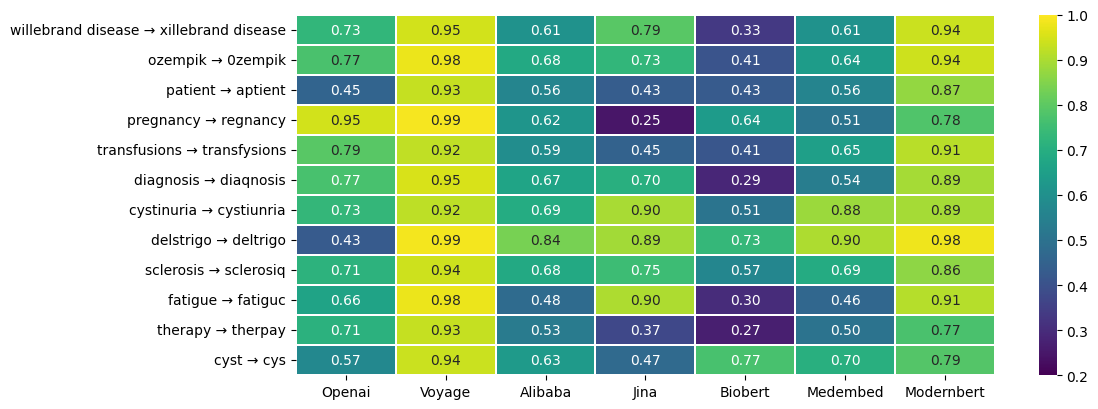

In [29]:
fig, ax = plt.subplots(figsize=(len(models) * 1.7, len(typos_df) * 0.35))

sns.heatmap(scores_matrix, annot=True, fmt=".2f", yticklabels=yticklabels,
            xticklabels=[model.capitalize() for model, *_ in models],
            cmap='viridis', linewidths=.25, ax=ax, vmin=0.2, vmax=1)

plt.tight_layout()
plt.show()

## Tokenization

In [30]:
results = {}

def tokenize_openai(typo):
    encoded = tokenizer_openai.encode(typo)
    result = [tokenizer_openai.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded]
    return result

results["openai"] = [
    " / ".join(["-".join(tokens) for tokens in (tokenize_openai(term), tokenize_openai(typos[term]))])
    for term in typos
]

In [31]:
for model, _, tokenizer in models[1:]:  # all but openai
    tokenizer_results = []
    special = tokenizer.all_special_ids

    for term in typos:
        encoded_term = tokenizer.encode(term)
        decoded_tokens = [tokenizer.decode([token]).replace("##", "") for token in encoded_term if token not in special]

        encoded_typo = tokenizer.encode(typos[term])
        decoded_typo_tokens = [tokenizer.decode([token]).replace("##", "") for token in encoded_typo if token not in special]

        tokenizer_results.append(f"{'-'.join(decoded_tokens)} / {'-'.join(decoded_typo_tokens)}")
    results[model] = tokenizer_results

pd.DataFrame(results, index=typos.keys()).head(20)

,openai,voyage,alibaba,jina,biobert,medembed,modernbert
willebrand disease,w-ille-brand-disease / x-ille-brand-disease,w-ille-brand-disease / x-ille-brand-disease,will-eb-rand-disease / xi-lle-brand-disease,will-e-brand-disease / x-ille-brand-disease,will-eb-rand-disease / x-ille-brand-disease,will-eb-rand-disease / xi-lle-brand-disease,w-ille-brand- disease / x-ille-brand- disease
ozempik,oz-emp-ik / 0-z-emp-ik,o-z-emp-ik / -0-z-emp-ik,oz-em-pi-k / 0-ze-mp-ik,o-zem-pik / 0-zem-pik,oz-em-pi-k / 0-ze-mp-ik,oz-em-pi-k / 0-ze-mp-ik,oz-emp-ik / 0-z-emp-ik
patient,patient / apt-ient,patient / apt-ient,patient / apt-ient,patient / a-pti-ent,patient / a-pt-ient,patient / apt-ient,patient / apt-ient
pregnancy,preg-n-ancy / regn-ancy,pre-gn-ancy / reg-n-ancy,pregnancy / reg-nan-cy,pre-gna-ncy / regna-ncy,pregnancy / re-gna-ncy,pregnancy / reg-nan-cy,p-regnancy / regnancy
transfusions,trans-f-usions / trans-f-ys-ions,trans-f-us-ions / trans-f-ys-ions,trans-fusion-s / trans-fy-sions,trans-fusion-s / transf-y-sions,trans-fusion-s / trans-fy-sions,trans-fusion-s / trans-fy-sions,trans-f-usions / trans-f-ys-ions
diagnosis,di-agnosis / dia-qn-osis,diagn-osis / dia-q-nos-is,diagnosis / dia-q-nosis,-diagnos-is / di-aq-nosi-s,diagnosis / di-aq-nosis,diagnosis / dia-q-nosis,diagn-osis / dia-qn-osis
cystinuria,c-yst-in-uria / c-yst-i-un-ria,c-yst-in-uria / c-yst-i-un-ria,cy-sti-nu-ria / cy-sti-un-ria,cyst-in-uria / cyst-i-un-ria,c-ys-tin-uria / c-ys-ti-un-ria,cy-sti-nu-ria / cy-sti-un-ria,cyst-in-uria / cy-sti-un-ria
delstrigo,del-str-igo / del-tr-igo,del-str-igo / del-tr-igo,del-st-ri-go / del-tri-go,del-stri-go / del-t-rigo,del-st-rig-o / del-tri-go,del-st-ri-go / del-tri-go,del-str-igo / del-tr-igo
sclerosis,s-clerosis / s-cl-eros-iq,s-cl-eros-is / s-cler-osi-q,sc-ler-osis / sc-ler-osi-q,sc-ler-osis / sc-ler-o-siq,s-cle-rosis / s-cle-ros-iq,sc-ler-osis / sc-ler-osi-q,s-clerosis / s-cler-osi-q
fatigue,fat-igue / fat-ig-uc,fat-igue / fat-ig-uc,fatigue / fat-ig-uc,fatigue / fati-gu-c,fatigue / fat-ig-uc,fatigue / fat-ig-uc,fat-igue / fat-ig-uc


# Domain terms

In [32]:
words = list(wordnet.words())
len(words)

147306

In [33]:
terms = [
    "lncRNA",  # Long non-coding RNAs with gene regulatory functions
    "BBB disruption therapy",  # Method of temporarily disrupting the blood-brain barrier to deliver drugs to brain tissue
    "Antisense oligonucleotide",  # Short synthetic DNA or RNA for therapy of genetic diseases and cancer
    "PD-L1 mAbs",  # Monoclonal antibodies helping the immune system recognize and destroy cancer cells
    "Kabuki syndrome",  # Rare genetic disorder
    "Waldenström Macroglobulinemia",  # A rare type of non-Hodgkin lymphoma
    "Frey syndrome",  # A condition causing facial sweating when eating
    "Metformin",  # Medication for Type 2 diabetes treatment (brand name Glucophage)
    "Ozempic",  # Drug for treating type 2 diabetes and weight management
    "Cladribine",  # Drug for treating multiple sclerosis
    "Zolgensma",  # Gene therapy for spinal muscular atrophy
    "ReoPro",  # Drug preventing blood clotting during vascular surgeries
]

In [34]:
terms_df = pd.DataFrame(terms, columns=["term"])
terms_df.head()

,term
0,lncRNA
1,BBB disruption therapy
2,Antisense oligonucleotide
3,PD-L1 mAbs
4,Kabuki syndrome


In [35]:
for model, method, _ in models:
    terms_embeddings = get_embeddings(terms_df["term"].tolist(), model, method)
    wordnet_embeddings = get_embeddings(words, model, method)
    similarities = cosine_similarity(terms_embeddings, wordnet_embeddings)

    results = []
    for term, term_similarities in zip(terms, similarities):
        top_indices = np.argsort(term_similarities)[-3:][::-1]
        top_words = [words[i] for i in top_indices]
        results.append(", ".join(top_words))

    terms_df[model] = results

terms_df.head(20)

Processing openai:   0%|          | 0/2 [00:00<?, ?it/s]

Processing openai:   0%|          | 0/18414 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/2 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/18414 [00:00<?, ?it/s]

Processing alibaba:   0%|          | 0/2 [00:00<?, ?it/s]

...

Processing medembed:   0%|          | 0/2 [00:00<?, ?it/s]

Processing medembed:   0%|          | 0/18414 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/2 [00:00<?, ?it/s]

Processing modernbert:   0%|          | 0/18414 [00:00<?, ?it/s]

,term,openai,voyage,alibaba,jina,biobert,medembed,modernbert
0,lncRNA,"nrna, nuclear_rna, informational_rna","nuclear_rna, mrna, rna","rna, informational_rna, mrna","nrna, rna, nrl","lunda, livistona, liliales","rna, nuclear_rna, nrna","mycophage, chalcid, flecainide"
1,BBB disruption therapy,"blood-brain_barrier, thrombolytic_therapy, clo...","therapeutic, therapy, therapeutical","implosion_therapy, disrupt, therapeutical","implosion_therapy, behavior_therapy, disruption","bobsledding, bd, boding","disruption, bb, bbs","feedlot, birthwort, bombastically"
2,Antisense oligonucleotide,"nucleoside, antimetabolite, dideoxyinosine","antibody, recombinant, isoantibody","nucleoside, didanosine, mrna",non-nucleoside_reverse_transcriptase_inhibitor...,"ribonucleic_acid, antineoplastic, knock-down","nucleotide, dna, endonuclease","queenfish, immensurable, antihistamine"
3,PD-L1 mAbs,"cancer_drug, immunotherapeutic, anti-tnf_compound","monoclonal, monoclonal_antibody, antibody","monoclonal_antibody, immunotherapeutic, monocl...","immunoglobulin_d, monoclonal_antibody, immunoa...","mam, lgb, mamma","monoclonal_antibody, monoclonal, pd","l-plate, hsv-2, 401-k_plan"
4,Kabuki syndrome,"kakke_disease, noonan's_syndrome, syndrome","syndrome, korsakoff's_syndrome, abasia","kallman's_syndrome, ekbom_syndrome, syndrome","ekbom_syndrome, akinesia, korsakoff's_syndrome","kaki, kalansuwa, kawaka","korzybski, kaki, ekbom_syndrome","giant_reed, cushaw, mortal_sin"
5,Waldenström Macroglobulinemia,"plasmacytoma, myeloma, gammopathy","agammaglobulinemia, hypogammaglobulinemia, gra...","agammaglobulinemia, multiple_myeloma, myeloma","agammaglobulinemia, myoglobinuria, megaloblast...","myoglobinuria, mulishness, hypogammaglobulinemia","agammaglobulinemia, waldenses, hypogammaglobul...","osteosclerosis_congenita, drepanocytic_anaemia..."
6,Frey syndrome,"hyperhidrosis, diaphoresis, polyhidrosis","syndrome, williams_syndrome, idiopathy","frey, bruxism, waterhouse-friderichsen_syndrome","syndrome, frey, reye's_syndrome","frey, freyr, freya","frey, freya, freyr","frostwort, foumart, fortunella"
7,Metformin,"metformin, glucophage, glipizide","metformin, glyburide, antidiabetic","metformin, sulfonylurea, antidiabetic","metformin, methionine, metharbital","metformin, metrazol, methotrexate","metformin, methedrine, statin","metformin, methionine, meteor"
8,Ozempic,"glucophage, glipizide, zapotecan","otic, zocor, empirin","ozena, obidoxime_chloride, oxyphencyclimine","ocimum, omotic, oecumenic","ozena, ozarks, ozaena","ozonize, typic, ozonide","palometa, pseudemys, empyreal"
9,Cladribine,"chlorambucil, leukeran, mercaptopurine","clonidine, chlorpromazine, clomipramine","zalcitabine, lamivudine, deoxyadenosine","cladrastis, clerid, clinid","cladonia, cladrastis, cladode","clad, cladode, zalcitabine","cladoniaceae, cladophyll, cicadellidae"
